✅ OpenCV already installed
✅ Matplotlib already installed
✅ Pillow already installed
✅ All required packages are already installed!

📚 Importing packages...
✅ All packages imported successfully!

✅ Results directory created: /home/jovyan/path_planning_results

📁 Current working directory: /home/jovyan
📁 Results will be saved to: /home/jovyan/path_planning_results

PATH PLANNING ASSIGNMENT - A* vs RRT vs RRT*
✅ Map loaded: E.png


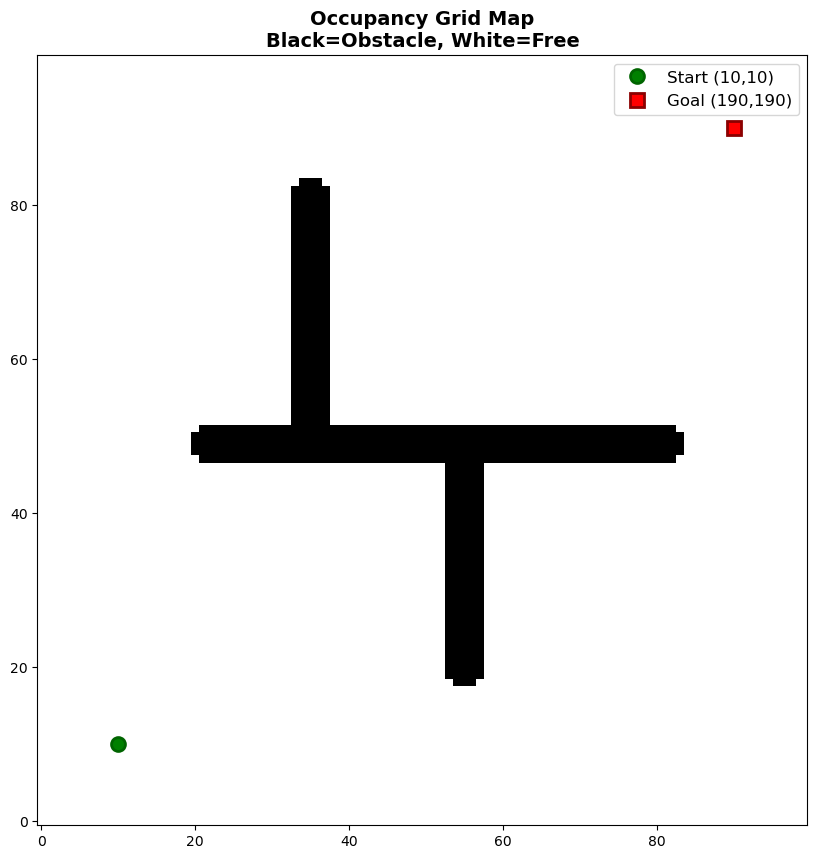


📊 Map Info:
  - Dimensions: 200x200 pixels
  - Free space: 9383 pixels (93.8%)
  - Obstacles: 617 pixels (6.2%)

🚀 Running A* Algorithm...
✅ A* Results:
  - Time: 0.1086 seconds
  - Nodes expanded: 6456
  - Path length: 135.98 pixels

🌳 Running RRT Algorithm...
✅ RRT Results:
  - Time: 0.0242 seconds
  - Total nodes: 119
  - Path length: 160.10 pixels

⭐ Running RRT* Algorithm...
  RRT* Found better path! Iter 453, Length: 134.47
  RRT* Iteration 2000/6000, Nodes: 1723, Best path: 134.47
  RRT* Iteration 3000/6000, Nodes: 2668, Best path: 134.47
  RRT* Iteration 4000/6000, Nodes: 3613, Best path: 134.47
  RRT* Iteration 5000/6000, Nodes: 4571, Best path: 134.47
  RRT* Iteration 6000/6000, Nodes: 5528, Best path: 134.47
✅ RRT* Results:
  - Time: 127.6343 seconds
  - Total nodes: 5528
  - Path length: 134.47 pixels

📊 Generating Individual Algorithm Visualizations...


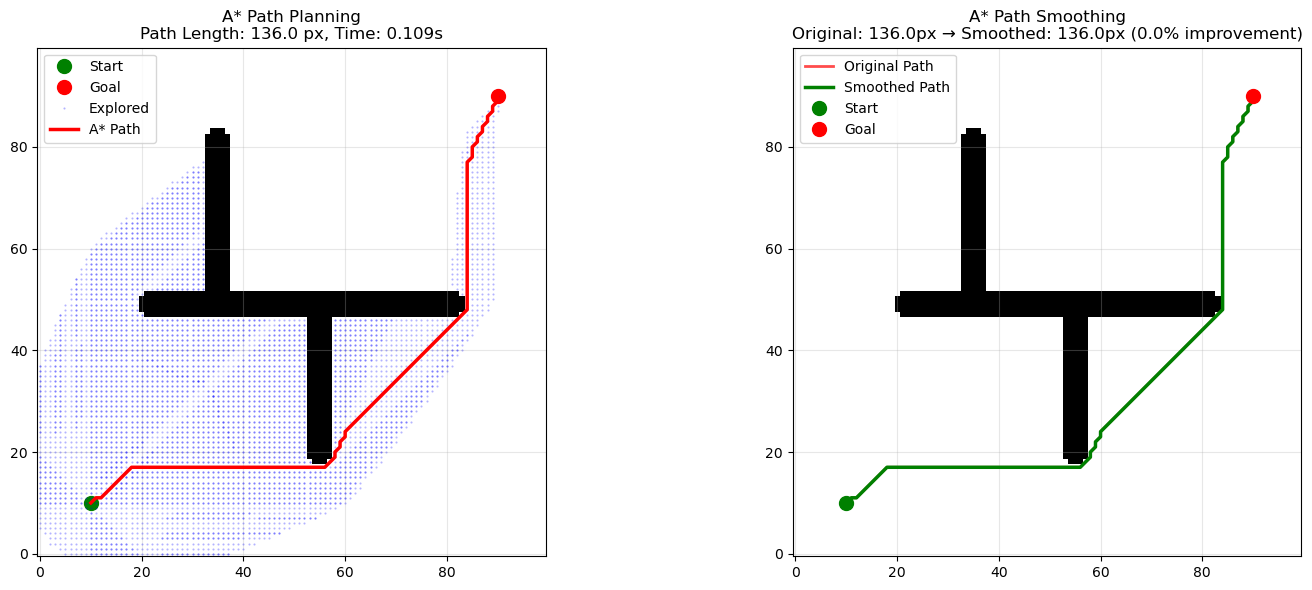

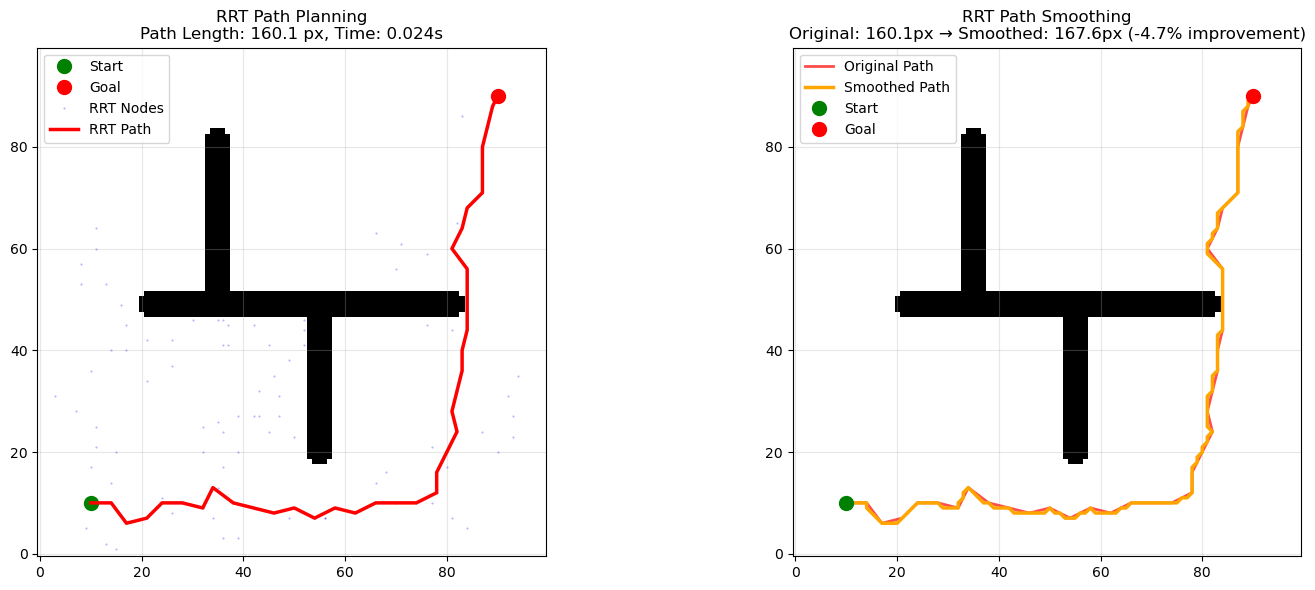

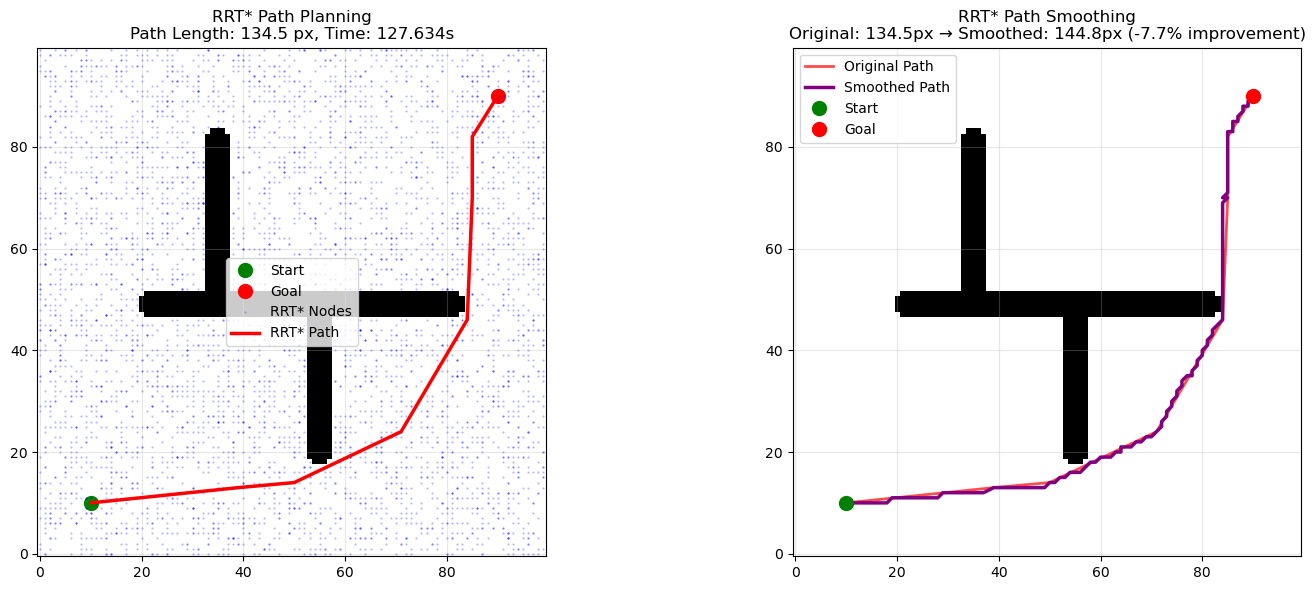


📊 Generating Comparison of All Algorithms...


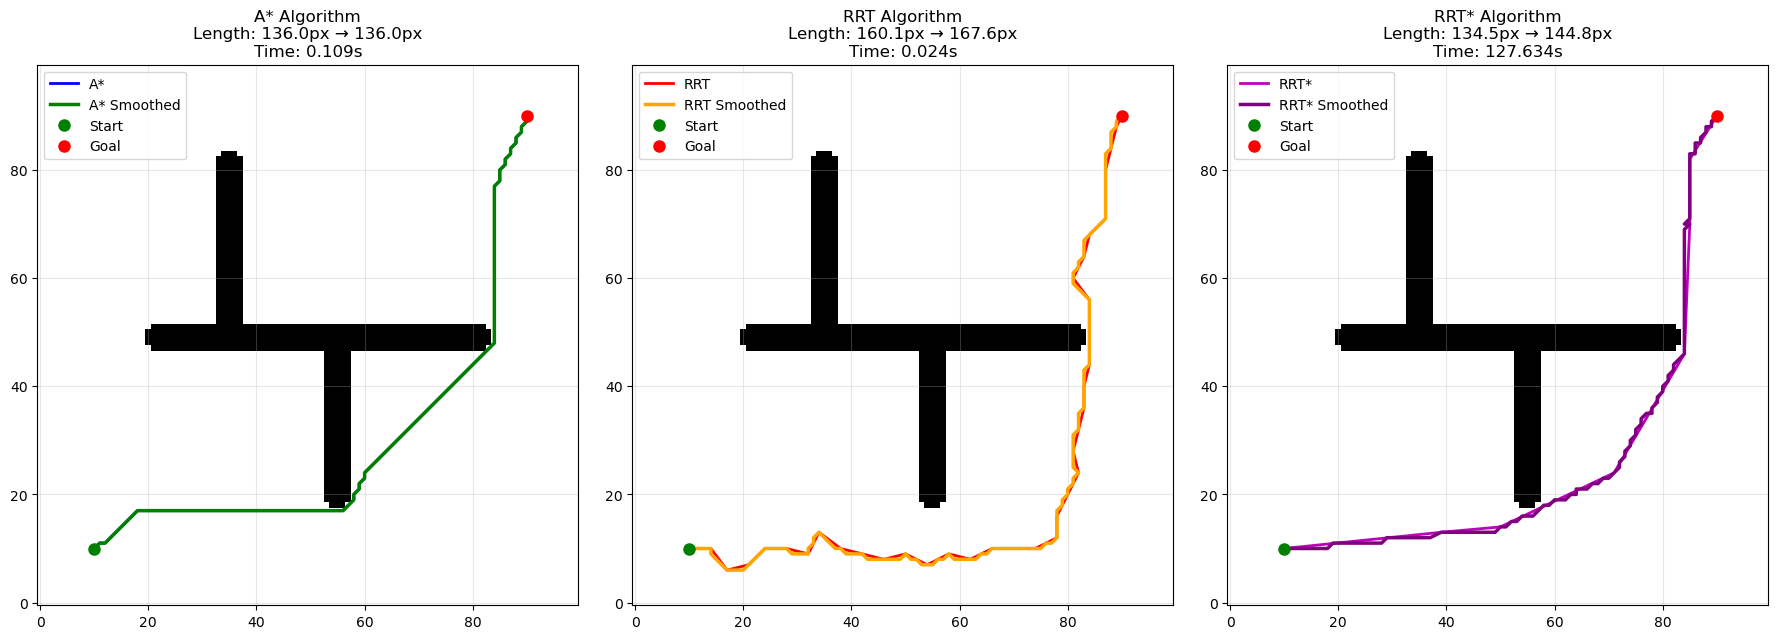


📊 METRICS COMPARISON TABLE
Algorithm    Time (s)     Nodes/Points    Original Len Smoothed Len Improvement 
-------------------------------------------------------------------------------------
A*           0.1086       6456            135.98       135.98       0.00        %
RRT          0.0242       119             160.10       167.64       -4.71       %
RRT*         127.6343     5528            134.47       144.83       -7.71       %


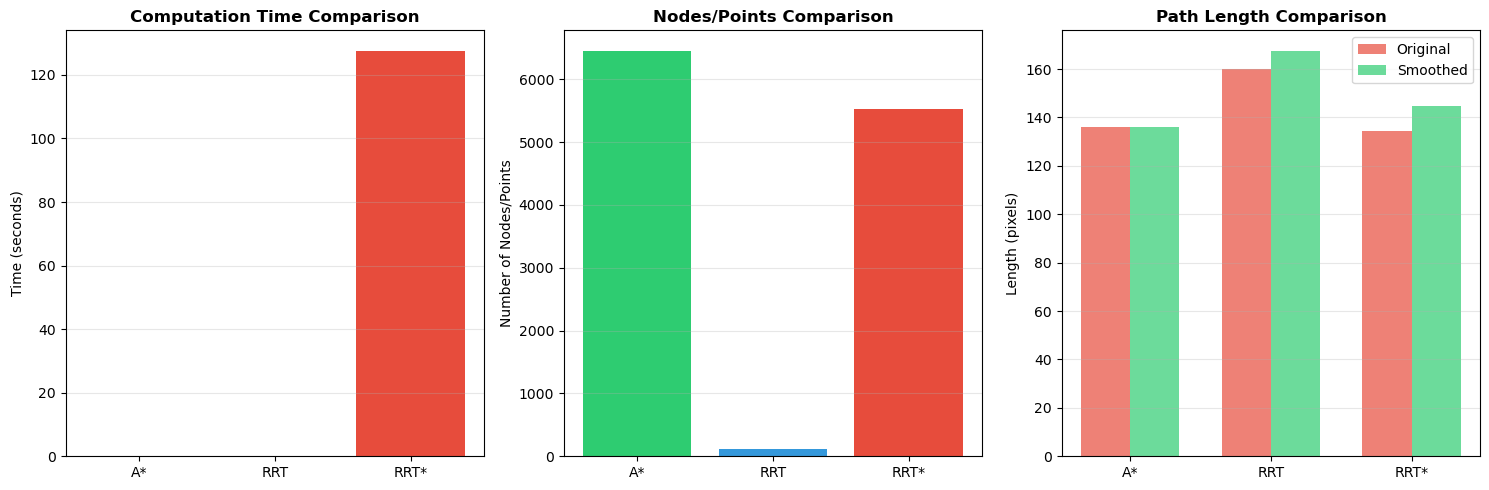


🎬 Creating Animations...
  📹 AStar: Creating animation with 6456 frames...
  Creating AStar animation...
     AStar: 0/6456 frames (0.0%)
     AStar: 0/6456 frames (0.0%)
     AStar: 50/6456 frames (0.8%)
     AStar: 100/6456 frames (1.5%)
     AStar: 150/6456 frames (2.3%)
     AStar: 200/6456 frames (3.1%)
     AStar: 250/6456 frames (3.9%)
     AStar: 300/6456 frames (4.6%)
     AStar: 350/6456 frames (5.4%)
     AStar: 400/6456 frames (6.2%)
     AStar: 450/6456 frames (7.0%)
     AStar: 500/6456 frames (7.7%)
     AStar: 550/6456 frames (8.5%)
     AStar: 600/6456 frames (9.3%)
     AStar: 650/6456 frames (10.1%)
     AStar: 700/6456 frames (10.8%)
     AStar: 750/6456 frames (11.6%)
     AStar: 800/6456 frames (12.4%)
     AStar: 850/6456 frames (13.2%)
     AStar: 900/6456 frames (13.9%)
     AStar: 950/6456 frames (14.7%)
     AStar: 1000/6456 frames (15.5%)
     AStar: 1050/6456 frames (16.3%)
     AStar: 1100/6456 frames (17.0%)
     AStar: 1150/6456 frames (17.8%)
     ASta

In [1]:
# ============================================================================
# INSTALL ALL REQUIRED PACKAGES
# ============================================================================

import sys
import subprocess

def install_packages():
    """Install all required packages if missing"""
    packages_to_install = []
    
    try:
        import cv2
        print("✅ OpenCV already installed")
    except ImportError:
        packages_to_install.append('opencv-python')
    
    try:
        import matplotlib
        print("✅ Matplotlib already installed")
    except ImportError:
        packages_to_install.append('matplotlib')
    
    try:
        import PIL
        print("✅ Pillow already installed")
    except ImportError:
        packages_to_install.append('pillow')
    
    if packages_to_install:
        print(f"📦 Installing: {', '.join(packages_to_install)}")
        for package in packages_to_install:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print("✅ All packages installed!")
    else:
        print("✅ All required packages are already installed!")

# Run installation check
install_packages()

# Now import all packages
print("\n📚 Importing packages...")
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cv2
import time
import os
import heapq
import math
from IPython.display import display, HTML

print("✅ All packages imported successfully!")
print("="*60)

# ============================================================================
# 0. Setup & Environment
# ============================================================================

# Create results directory in current working directory
CURRENT_DIR = os.getcwd()
RESULTS_DIR = os.path.join(CURRENT_DIR, "path_planning_results")

# Create the directory
try:
    os.makedirs(RESULTS_DIR, exist_ok=True)
    print(f"\n✅ Results directory created: {RESULTS_DIR}")
except Exception as e:
    print(f"⚠️  Could not create {RESULTS_DIR}, using current directory")
    RESULTS_DIR = CURRENT_DIR

print(f"\n📁 Current working directory: {CURRENT_DIR}")
print(f"📁 Results will be saved to: {RESULTS_DIR}")

print("\n" + "="*60)
print("PATH PLANNING ASSIGNMENT - A* vs RRT vs RRT*")
print("="*60)

# ============================================================================
# 1. Load Custom Map
# ============================================================================
# map_path = "./AR5_MAP.png"
map_path = "E.png"

# Define start and goal
START = (10, 10)        # (x, y) - bottom-left corner
GOAL = (90, 90)       # (x, y) - top-right corner

# Check if file exists or use default
if not map_path:
    print("\n⚠️  No file provided, creating default test map...")
    MAP_SIZE = 200
    map_img = np.ones((MAP_SIZE, MAP_SIZE), dtype=np.uint8) * 255
    
    # Create a maze-like structure with narrow corridors
    # Vertical walls
    for x in range(30, MAP_SIZE-30, 40):
        map_img[10:MAP_SIZE-10, x:x+3] = 0
        if x % 80 == 0:
            gate_y = MAP_SIZE // 2
            map_img[gate_y-10:gate_y+10, x:x+3] = 255
    
    # Horizontal walls
    for y in range(40, MAP_SIZE-40, 45):
        map_img[y:y+3, 10:MAP_SIZE-10] = 0
        if y % 90 == 0:
            gate_x = MAP_SIZE // 2
            map_img[y:y+3, gate_x-10:gate_x+10] = 255
    
    # Random narrow corridors
    for _ in range(30):
        x = np.random.randint(20, MAP_SIZE-20)
        y = np.random.randint(20, MAP_SIZE-20)
        map_img[y:y+5, x:x+2] = 0
    
    # Ensure start and goal are free
    map_img[START[1]-2:START[1]+3, START[0]-2:START[0]+3] = 255
    map_img[GOAL[1]-2:GOAL[1]+3, GOAL[0]-2:GOAL[0]+3] = 255
    
    print("✅ Created default test map (200x200 with obstacles)")
    
elif os.path.exists(map_path):
    map_img = cv2.imread(map_path, cv2.IMREAD_GRAYSCALE)
    
    if map_img is None:
        print(f"❌ Error: Could not load image from {map_path}")
        print("Creating default test map instead...")
        MAP_SIZE = 200
        map_img = np.ones((MAP_SIZE, MAP_SIZE), dtype=np.uint8) * 255
    else:
        print(f"✅ Map loaded: {map_path}")
        
        # if map_img.shape[0] != 200 or map_img.shape[1] != 200:
        #     print(f"⚠️  Resizing map to 200x200")
        #     map_img = cv2.resize(map_img, (200, 200), interpolation=cv2.INTER_NEAREST)
        
        map_img = cv2.threshold(map_img, 127, 255, cv2.THRESH_BINARY)[1]
else:
    print(f"❌ File not found: {map_path}")
    print("Creating default test map instead...")
    MAP_SIZE = 200
    map_img = np.ones((MAP_SIZE, MAP_SIZE), dtype=np.uint8) * 255

# Ensure start and goal are free
if map_img[START[1], START[0]] != 255:
    map_img[START[1], START[0]] = 255
if map_img[GOAL[1], GOAL[0]] != 255:
    map_img[GOAL[1], GOAL[0]] = 255

# Save map
cv2.imwrite(os.path.join(RESULTS_DIR, "custom_map.png"), map_img)

# Visualize map
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')
plt.plot(START[0], START[1], 'go', markersize=10, markeredgecolor='darkgreen', markeredgewidth=2, label='Start (10,10)')
plt.plot(GOAL[0], GOAL[1], 'rs', markersize=10, markeredgecolor='darkred', markeredgewidth=2, label='Goal (90,90)')
plt.title(f"Occupancy Grid Map\nBlack=Obstacle, White=Free", fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(False)
plt.savefig(os.path.join(RESULTS_DIR, "custom_map_visualization.png"), dpi=150, bbox_inches='tight')
plt.show()

free_pixels = np.sum(map_img == 255)
total_pixels = map_img.size
print(f"\n📊 Map Info:")
print(f"  - Dimensions: 100x100 pixels")
print(f"  - Free space: {free_pixels} pixels ({free_pixels/total_pixels*100:.1f}%)")
print(f"  - Obstacles: {total_pixels - free_pixels} pixels ({(total_pixels - free_pixels)/total_pixels*100:.1f}%)")

# ============================================================================
# 2. A* Algorithm
# ============================================================================

class AStarPlanner:
    def __init__(self, grid, start, goal):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.height, self.width = grid.shape
        
    def heuristic(self, a, b):
        return np.hypot(a[0] - b[0], a[1] - b[1])
    
    def get_neighbors(self, node):
        neighbors = []
        for dx, dy in [(1,0), (-1,0), (0,1), (0,-1), (1,1), (1,-1), (-1,1), (-1,-1)]:
            nx, ny = node[0] + dx, node[1] + dy
            if 0 <= nx < self.width and 0 <= ny < self.height:
                if self.grid[ny, nx] == 255:
                    cost = 1.414 if dx != 0 and dy != 0 else 1.0
                    neighbors.append((nx, ny, cost))
        return neighbors
    
    def plan(self):
        open_set = []
        heapq.heappush(open_set, (0, self.start))
        came_from = {}
        g_score = {self.start: 0}
        f_score = {self.start: self.heuristic(self.start, self.goal)}
        visited_nodes = []
        expanded_count = 0
        
        while open_set:
            current = heapq.heappop(open_set)[1]
            expanded_count += 1
            visited_nodes.append(current)
            
            if current == self.goal:
                path = []
                while current in came_from:
                    path.append(current)
                    current = came_from[current]
                path.append(self.start)
                path.reverse()
                return path, visited_nodes, expanded_count
            
            for nx, ny, move_cost in self.get_neighbors(current):
                neighbor = (nx, ny)
                tentative_g = g_score[current] + move_cost
                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + self.heuristic(neighbor, self.goal)
                    heapq.heappush(open_set, (f_score[neighbor], neighbor))
        
        return None, visited_nodes, expanded_count

# Run A*
print("\n" + "="*60)
print("🚀 Running A* Algorithm...")
print("="*60)
start_time = time.time()
astar = AStarPlanner(map_img, START, GOAL)
astar_path, astar_visited, astar_expanded = astar.plan()
astar_time = time.time() - start_time

if astar_path:
    astar_length = sum(np.hypot(astar_path[i+1][0]-astar_path[i][0], 
                                 astar_path[i+1][1]-astar_path[i][1]) 
                       for i in range(len(astar_path)-1))
    print(f"✅ A* Results:")
    print(f"  - Time: {astar_time:.4f} seconds")
    print(f"  - Nodes expanded: {astar_expanded}")
    print(f"  - Path length: {astar_length:.2f} pixels")
else:
    print("❌ A* could not find a path!")
    astar_length = 0

# ============================================================================
# 3. RRT Algorithm
# ============================================================================

class RRTPlanner:
    def __init__(self, grid, start, goal, max_iter=6000, step_size=5, goal_sample_rate=0.1):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.max_iter = max_iter
        self.step_size = step_size
        self.goal_sample_rate = goal_sample_rate
        self.height, self.width = grid.shape
        self.nodes = [start]
        self.parents = {start: None}
        
    def is_collision_free(self, p1, p2):
        x1, y1 = p1
        x2, y2 = p2
        dist = max(abs(x2-x1), abs(y2-y1))
        if dist == 0:
            return True
        for i in range(dist+1):
            t = i / dist
            x = int(x1 + t*(x2-x1))
            y = int(y1 + t*(y2-y1))
            if not (0 <= x < self.width and 0 <= y < self.height):
                return False
            if self.grid[y, x] == 0:
                return False
        return True
    
    def sample_random_point(self):
        if np.random.random() < self.goal_sample_rate:
            return self.goal
        return (np.random.randint(0, self.width), np.random.randint(0, self.height))
    
    def nearest_neighbor(self, point):
        distances = [np.hypot(point[0]-n[0], point[1]-n[1]) for n in self.nodes]
        return self.nodes[np.argmin(distances)]
    
    def steer(self, from_node, to_point):
        dist = np.hypot(to_point[0]-from_node[0], to_point[1]-from_node[1])
        if dist <= self.step_size:
            return to_point
        theta = np.arctan2(to_point[1]-from_node[1], to_point[0]-from_node[0])
        new_x = from_node[0] + self.step_size * np.cos(theta)
        new_y = from_node[1] + self.step_size * np.sin(theta)
        return (int(new_x), int(new_y))
    
    def plan(self):
        all_nodes_history = []
        
        for i in range(self.max_iter):
            sample = self.sample_random_point()
            nearest = self.nearest_neighbor(sample)
            new_node = self.steer(nearest, sample)
            
            if not self.is_collision_free(nearest, new_node):
                continue
            
            self.parents[new_node] = nearest
            self.nodes.append(new_node)
            all_nodes_history.append(new_node)
            
            if self.is_collision_free(new_node, self.goal) and np.hypot(new_node[0]-self.goal[0], new_node[1]-self.goal[1]) < self.step_size:
                self.parents[self.goal] = new_node
                path = []
                current = self.goal
                while current is not None:
                    path.append(current)
                    current = self.parents[current]
                path.reverse()
                return path, all_nodes_history, len(self.nodes)
            
            if (i+1) % 1000 == 0:
                print(f"  RRT Iteration {i+1}/{self.max_iter}, Nodes: {len(self.nodes)}")
        
        return None, all_nodes_history, len(self.nodes)

# Run RRT
print("\n" + "="*60)
print("🌳 Running RRT Algorithm...")
print("="*60)
start_time = time.time()
rrt = RRTPlanner(map_img, START, GOAL, max_iter=6000, step_size=5, goal_sample_rate=0.1)
rrt_path, rrt_nodes, rrt_total_nodes = rrt.plan()
rrt_time = time.time() - start_time

if rrt_path:
    rrt_length = sum(np.hypot(rrt_path[i+1][0]-rrt_path[i][0], 
                              rrt_path[i+1][1]-rrt_path[i][1]) 
                     for i in range(len(rrt_path)-1))
    print(f"✅ RRT Results:")
    print(f"  - Time: {rrt_time:.4f} seconds")
    print(f"  - Total nodes: {rrt_total_nodes}")
    print(f"  - Path length: {rrt_length:.2f} pixels")
else:
    print("❌ RRT could not find a path!")
    rrt_length = 0

# ============================================================================
# 4. RRT* Algorithm
# ============================================================================

class RRTStarPlanner:
    def __init__(self, grid, start, goal, max_iter=6000, step_size=5, goal_sample_rate=0.1, radius=30):
        self.grid = grid
        self.start = start
        self.goal = goal
        self.max_iter = max_iter
        self.step_size = step_size
        self.goal_sample_rate = goal_sample_rate
        self.radius = radius
        self.height, self.width = grid.shape
        self.nodes = [start]
        self.parents = {start: None}
        self.costs = {start: 0}
        
    def is_collision_free(self, p1, p2):
        x1, y1 = p1
        x2, y2 = p2
        dist = max(abs(x2-x1), abs(y2-y1))
        if dist == 0:
            return True
        for i in range(dist+1):
            t = i / dist
            x = int(x1 + t*(x2-x1))
            y = int(y1 + t*(y2-y1))
            if not (0 <= x < self.width and 0 <= y < self.height):
                return False
            if self.grid[y, x] == 0:
                return False
        return True
    
    def sample_random_point(self):
        if np.random.random() < self.goal_sample_rate:
            return self.goal
        return (np.random.randint(0, self.width), np.random.randint(0, self.height))
    
    def nearest_neighbor(self, point):
        distances = [np.hypot(point[0]-n[0], point[1]-n[1]) for n in self.nodes]
        return self.nodes[np.argmin(distances)]
    
    def steer(self, from_node, to_point):
        dist = np.hypot(to_point[0]-from_node[0], to_point[1]-from_node[1])
        if dist <= self.step_size:
            return to_point
        theta = np.arctan2(to_point[1]-from_node[1], to_point[0]-from_node[0])
        new_x = from_node[0] + self.step_size * np.cos(theta)
        new_y = from_node[1] + self.step_size * np.sin(theta)
        return (int(new_x), int(new_y))
    
    def find_near_nodes(self, node):
        near_nodes = []
        for n in self.nodes:
            dist = np.hypot(node[0]-n[0], node[1]-n[1])
            if dist <= self.radius:
                near_nodes.append(n)
        return near_nodes
    
    def choose_parent(self, node, near_nodes):
        min_cost = float('inf')
        best_parent = None
        
        for near in near_nodes:
            if self.is_collision_free(near, node):
                new_cost = self.costs[near] + np.hypot(node[0]-near[0], node[1]-near[1])
                if new_cost < min_cost:
                    min_cost = new_cost
                    best_parent = near
        return best_parent, min_cost
    
    def rewire(self, node, near_nodes):
        for near in near_nodes:
            if near == node:
                continue
            new_cost = self.costs[node] + np.hypot(near[0]-node[0], near[1]-node[1])
            if new_cost < self.costs[near] and self.is_collision_free(node, near):
                self.parents[near] = node
                self.costs[near] = new_cost
    
    def plan(self):
        all_nodes_history = []
        best_path = None
        best_path_length = float('inf')
        
        for i in range(self.max_iter):
            sample = self.sample_random_point()
            nearest = self.nearest_neighbor(sample)
            new_node = self.steer(nearest, sample)
            
            if not self.is_collision_free(nearest, new_node):
                continue
            
            near_nodes = self.find_near_nodes(new_node)
            best_parent, min_cost = self.choose_parent(new_node, near_nodes)
            
            if best_parent is not None:
                self.parents[new_node] = best_parent
                self.costs[new_node] = min_cost
                self.nodes.append(new_node)
                all_nodes_history.append(new_node)
                self.rewire(new_node, near_nodes)
            
            # Try to connect to goal
            if self.is_collision_free(new_node, self.goal):
                dist_to_goal = np.hypot(new_node[0]-self.goal[0], new_node[1]-self.goal[1])
                if dist_to_goal < self.step_size * 2:
                    goal_cost = self.costs[new_node] + dist_to_goal
                    if self.goal not in self.parents or goal_cost < self.costs.get(self.goal, float('inf')):
                        self.parents[self.goal] = new_node
                        self.costs[self.goal] = goal_cost
                        self.nodes.append(self.goal)
                        
                        # Extract path
                        path = []
                        current = self.goal
                        while current is not None:
                            path.append(current)
                            current = self.parents[current]
                        path.reverse()
                        
                        # Calculate path length
                        path_len = sum(np.hypot(path[i+1][0]-path[i][0], path[i+1][1]-path[i][1]) 
                                      for i in range(len(path)-1))
                        
                        if path_len < best_path_length:
                            best_path_length = path_len
                            best_path = path
                            print(f"  RRT* Found better path! Iter {i}, Length: {best_path_length:.2f}")
            
            if (i+1) % 1000 == 0:
                status = f"Best path: {best_path_length:.2f}" if best_path_length != float('inf') else "No path yet"
                print(f"  RRT* Iteration {i+1}/{self.max_iter}, Nodes: {len(self.nodes)}, {status}")
        
        return best_path, all_nodes_history, len(self.nodes)

# Run RRT*
print("\n" + "="*60)
print("⭐ Running RRT* Algorithm...")
print("="*60)
start_time = time.time()
rrt_star = RRTStarPlanner(map_img, START, GOAL, max_iter=6000, step_size=5, goal_sample_rate=0.1, radius=30)
rrt_star_path, rrt_star_nodes, rrt_star_total_nodes = rrt_star.plan()
rrt_star_time = time.time() - start_time

if rrt_star_path:
    rrt_star_length = sum(np.hypot(rrt_star_path[i+1][0]-rrt_star_path[i][0], 
                                   rrt_star_path[i+1][1]-rrt_star_path[i][1]) 
                          for i in range(len(rrt_star_path)-1))
    print(f"✅ RRT* Results:")
    print(f"  - Time: {rrt_star_time:.4f} seconds")
    print(f"  - Total nodes: {rrt_star_total_nodes}")
    print(f"  - Path length: {rrt_star_length:.2f} pixels")
else:
    print("❌ RRT* could not find a path!")
    rrt_star_length = 0

# ============================================================================
# 5. Path Smoothing
# ============================================================================

def smooth_path_bezier(path, num_points=200):
    if not path or len(path) < 2:
        return path
    
    smoothed = []
    for i in range(len(path)-1):
        p0 = np.array(path[i])
        p1 = np.array(path[i+1])
        
        steps = max(5, num_points // max(len(path), 1))
        for t in np.linspace(0, 1, steps):
            point = p0 * (1-t) + p1 * t
            smoothed.append(tuple(point.astype(int)))
    
    smoothed.append(path[-1])
    seen = set()
    unique_smoothed = []
    for p in smoothed:
        if p not in seen:
            seen.add(p)
            unique_smoothed.append(p)
    
    return unique_smoothed

# Smooth all paths
astar_smoothed = smooth_path_bezier(astar_path) if astar_path else None
rrt_smoothed = smooth_path_bezier(rrt_path) if rrt_path else None
rrt_star_smoothed = smooth_path_bezier(rrt_star_path) if rrt_star_path else None

# Calculate smoothed lengths
astar_smoothed_length = 0
rrt_smoothed_length = 0
rrt_star_smoothed_length = 0

if astar_smoothed:
    astar_smoothed_length = sum(np.hypot(astar_smoothed[i+1][0]-astar_smoothed[i][0],
                                         astar_smoothed[i+1][1]-astar_smoothed[i][1]) 
                                for i in range(len(astar_smoothed)-1))

if rrt_smoothed:
    rrt_smoothed_length = sum(np.hypot(rrt_smoothed[i+1][0]-rrt_smoothed[i][0],
                                       rrt_smoothed[i+1][1]-rrt_smoothed[i][1]) 
                              for i in range(len(rrt_smoothed)-1))

if rrt_star_smoothed:
    rrt_star_smoothed_length = sum(np.hypot(rrt_star_smoothed[i+1][0]-rrt_star_smoothed[i][0],
                                            rrt_star_smoothed[i+1][1]-rrt_star_smoothed[i][1]) 
                                   for i in range(len(rrt_star_smoothed)-1))

# ============================================================================
# 6. Individual Algorithm Visualizations (with Original and Smoothed)
# ============================================================================

print("\n" + "="*60)
print("📊 Generating Individual Algorithm Visualizations...")
print("="*60)

# A* Visualization
if astar_path:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: A* with exploration
    axes[0].imshow(map_img, cmap='gray', origin='lower')
    axes[0].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[0].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    if len(astar_visited) > 5000:
        sampled = astar_visited[::len(astar_visited)//5000]
    else:
        sampled = astar_visited
    axes[0].plot([p[0] for p in sampled], [p[1] for p in sampled], 'b.', markersize=1, alpha=0.3, label='Explored')
    axes[0].plot([p[0] for p in astar_path], [p[1] for p in astar_path], 'r-', linewidth=2.5, label='A* Path')
    axes[0].set_title(f'A* Path Planning\nPath Length: {astar_length:.1f} px, Time: {astar_time:.3f}s')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Right: A* Original vs Smoothed
    axes[1].imshow(map_img, cmap='gray', origin='lower')
    axes[1].plot([p[0] for p in astar_path], [p[1] for p in astar_path], 'r-', linewidth=2, label='Original Path', alpha=0.7)
    axes[1].plot([p[0] for p in astar_smoothed], [p[1] for p in astar_smoothed], 'g-', linewidth=2.5, label='Smoothed Path')
    axes[1].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[1].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    improvement = ((astar_length - astar_smoothed_length)/astar_length*100) if astar_smoothed_length else 0
    axes[1].set_title(f'A* Path Smoothing\nOriginal: {astar_length:.1f}px → Smoothed: {astar_smoothed_length:.1f}px ({improvement:.1f}% improvement)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "astar_full_visualization.png"), dpi=150, bbox_inches='tight')
    plt.show()

# RRT Visualization
if rrt_path:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: RRT with tree
    axes[0].imshow(map_img, cmap='gray', origin='lower')
    axes[0].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[0].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    if rrt_nodes:
        axes[0].plot([p[0] for p in rrt_nodes], [p[1] for p in rrt_nodes], 'b.', markersize=1, alpha=0.3, label='RRT Nodes')
    axes[0].plot([p[0] for p in rrt_path], [p[1] for p in rrt_path], 'r-', linewidth=2.5, label='RRT Path')
    axes[0].set_title(f'RRT Path Planning\nPath Length: {rrt_length:.1f} px, Time: {rrt_time:.3f}s')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Right: RRT Original vs Smoothed
    axes[1].imshow(map_img, cmap='gray', origin='lower')
    axes[1].plot([p[0] for p in rrt_path], [p[1] for p in rrt_path], 'r-', linewidth=2, label='Original Path', alpha=0.7)
    axes[1].plot([p[0] for p in rrt_smoothed], [p[1] for p in rrt_smoothed], 'orange', linewidth=2.5, label='Smoothed Path')
    axes[1].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[1].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    improvement = ((rrt_length - rrt_smoothed_length)/rrt_length*100) if rrt_smoothed_length else 0
    axes[1].set_title(f'RRT Path Smoothing\nOriginal: {rrt_length:.1f}px → Smoothed: {rrt_smoothed_length:.1f}px ({improvement:.1f}% improvement)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "rrt_full_visualization.png"), dpi=150, bbox_inches='tight')
    plt.show()

# RRT* Visualization
if rrt_star_path:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: RRT* with tree
    axes[0].imshow(map_img, cmap='gray', origin='lower')
    axes[0].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[0].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    if rrt_star_nodes:
        axes[0].plot([p[0] for p in rrt_star_nodes], [p[1] for p in rrt_star_nodes], 'b.', markersize=1, alpha=0.3, label='RRT* Nodes')
    axes[0].plot([p[0] for p in rrt_star_path], [p[1] for p in rrt_star_path], 'r-', linewidth=2.5, label='RRT* Path')
    axes[0].set_title(f'RRT* Path Planning\nPath Length: {rrt_star_length:.1f} px, Time: {rrt_star_time:.3f}s')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Right: RRT* Original vs Smoothed
    axes[1].imshow(map_img, cmap='gray', origin='lower')
    axes[1].plot([p[0] for p in rrt_star_path], [p[1] for p in rrt_star_path], 'r-', linewidth=2, label='Original Path', alpha=0.7)
    axes[1].plot([p[0] for p in rrt_star_smoothed], [p[1] for p in rrt_star_smoothed], 'purple', linewidth=2.5, label='Smoothed Path')
    axes[1].plot(START[0], START[1], 'go', markersize=10, label='Start')
    axes[1].plot(GOAL[0], GOAL[1], 'ro', markersize=10, label='Goal')
    improvement = ((rrt_star_length - rrt_star_smoothed_length)/rrt_star_length*100) if rrt_star_smoothed_length else 0
    axes[1].set_title(f'RRT* Path Smoothing\nOriginal: {rrt_star_length:.1f}px → Smoothed: {rrt_star_smoothed_length:.1f}px ({improvement:.1f}% improvement)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "rrt_star_full_visualization.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# 7. Comparison of All Algorithms
# ============================================================================

print("\n" + "="*60)
print("📊 Generating Comparison of All Algorithms...")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A* comparison
if astar_path:
    axes[0].imshow(map_img, cmap='gray', origin='lower')
    axes[0].plot([p[0] for p in astar_path], [p[1] for p in astar_path], 'b-', linewidth=2, label='A*')
    if astar_smoothed:
        axes[0].plot([p[0] for p in astar_smoothed], [p[1] for p in astar_smoothed], 'g-', linewidth=2.5, label='A* Smoothed')
    axes[0].plot(START[0], START[1], 'go', markersize=8, label='Start')
    axes[0].plot(GOAL[0], GOAL[1], 'ro', markersize=8, label='Goal')
    axes[0].set_title(f'A* Algorithm\nLength: {astar_length:.1f}px → {astar_smoothed_length:.1f}px\nTime: {astar_time:.3f}s')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# RRT comparison
if rrt_path:
    axes[1].imshow(map_img, cmap='gray', origin='lower')
    axes[1].plot([p[0] for p in rrt_path], [p[1] for p in rrt_path], 'r-', linewidth=2, label='RRT')
    if rrt_smoothed:
        axes[1].plot([p[0] for p in rrt_smoothed], [p[1] for p in rrt_smoothed], 'orange', linewidth=2.5, label='RRT Smoothed')
    axes[1].plot(START[0], START[1], 'go', markersize=8, label='Start')
    axes[1].plot(GOAL[0], GOAL[1], 'ro', markersize=8, label='Goal')
    axes[1].set_title(f'RRT Algorithm\nLength: {rrt_length:.1f}px → {rrt_smoothed_length:.1f}px\nTime: {rrt_time:.3f}s')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# RRT* comparison
if rrt_star_path:
    axes[2].imshow(map_img, cmap='gray', origin='lower')
    axes[2].plot([p[0] for p in rrt_star_path], [p[1] for p in rrt_star_path], 'm-', linewidth=2, label='RRT*')
    if rrt_star_smoothed:
        axes[2].plot([p[0] for p in rrt_star_smoothed], [p[1] for p in rrt_star_smoothed], 'purple', linewidth=2.5, label='RRT* Smoothed')
    axes[2].plot(START[0], START[1], 'go', markersize=8, label='Start')
    axes[2].plot(GOAL[0], GOAL[1], 'ro', markersize=8, label='Goal')
    axes[2].set_title(f'RRT* Algorithm\nLength: {rrt_star_length:.1f}px → {rrt_star_smoothed_length:.1f}px\nTime: {rrt_star_time:.3f}s')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "all_algorithms_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. Metrics Table
# ============================================================================

print("\n" + "="*60)
print("📊 METRICS COMPARISON TABLE")
print("="*60)
print(f"{'Algorithm':<12} {'Time (s)':<12} {'Nodes/Points':<15} {'Original Len':<12} {'Smoothed Len':<12} {'Improvement':<12}")
print("-"*85)

if astar_path:
    astar_imp = ((astar_length - astar_smoothed_length)/astar_length*100) if astar_smoothed_length else 0
    print(f"{'A*':<12} {astar_time:<12.4f} {astar_expanded:<15} {astar_length:<12.2f} {astar_smoothed_length:<12.2f} {astar_imp:<12.2f}%")

if rrt_path:
    rrt_imp = ((rrt_length - rrt_smoothed_length)/rrt_length*100) if rrt_smoothed_length else 0
    print(f"{'RRT':<12} {rrt_time:<12.4f} {rrt_total_nodes:<15} {rrt_length:<12.2f} {rrt_smoothed_length:<12.2f} {rrt_imp:<12.2f}%")

if rrt_star_path:
    rrt_star_imp = ((rrt_star_length - rrt_star_smoothed_length)/rrt_star_length*100) if rrt_star_smoothed_length else 0
    print(f"{'RRT*':<12} {rrt_star_time:<12.4f} {rrt_star_total_nodes:<15} {rrt_star_length:<12.2f} {rrt_star_smoothed_length:<12.2f} {rrt_star_imp:<12.2f}%")

# ============================================================================
# 9. Bar Chart Comparison
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

algorithms = []
times = []
nodes = []
orig_lengths = []
smooth_lengths = []

if astar_path:
    algorithms.append('A*')
    times.append(astar_time)
    nodes.append(astar_expanded)
    orig_lengths.append(astar_length)
    smooth_lengths.append(astar_smoothed_length)

if rrt_path:
    algorithms.append('RRT')
    times.append(rrt_time)
    nodes.append(rrt_total_nodes)
    orig_lengths.append(rrt_length)
    smooth_lengths.append(rrt_smoothed_length)

if rrt_star_path:
    algorithms.append('RRT*')
    times.append(rrt_star_time)
    nodes.append(rrt_star_total_nodes)
    orig_lengths.append(rrt_star_length)
    smooth_lengths.append(rrt_star_smoothed_length)

if algorithms:
    # Time comparison
    axes[0].bar(algorithms, times, color=['#2ecc71', '#3498db', '#e74c3c'][:len(algorithms)])
    axes[0].set_title('Computation Time Comparison', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Time (seconds)')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Nodes comparison
    axes[1].bar(algorithms, nodes, color=['#2ecc71', '#3498db', '#e74c3c'][:len(algorithms)])
    axes[1].set_title('Nodes/Points Comparison', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Nodes/Points')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Path length comparison
    x = np.arange(len(algorithms))
    width = 0.35
    axes[2].bar(x - width/2, orig_lengths, width, label='Original', color='#e74c3c', alpha=0.7)
    axes[2].bar(x + width/2, smooth_lengths, width, label='Smoothed', color='#2ecc71', alpha=0.7)
    axes[2].set_title('Path Length Comparison', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Length (pixels)')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(algorithms)
    axes[2].legend()
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "metrics_barcharts.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ============================================================================
# 10. Animations
# ============================================================================

print("\n" + "="*60)
print("🎬 Creating Animations...")
print("="*60)

def create_animation(path, nodes_history, map_img, start, goal, name, color='g-'):
    if not path or not nodes_history:
        print(f"  ⚠️  Cannot create animation for {name}")
        return
    total_frames = len(nodes_history)
    print(f"  📹 {name}: Creating animation with {total_frames} frames...")
    print(f"  Creating {name} animation...")
    fig, ax = plt.subplots(figsize=(8, 8))
    
    frames_to_show = min(len(nodes_history), 20**20)
    
    def animate(frame):
        if frame % 50 == 0:
            print(f"     {name}: {frame}/{total_frames} frames ({frame/total_frames*100:.1f}%)")
        ax.clear()
        ax.imshow(map_img, cmap='gray', origin='lower')
        
        if frame < len(nodes_history):
            current_nodes = nodes_history[:frame]
            if current_nodes:
                ax.plot([p[0] for p in current_nodes], [p[1] for p in current_nodes], 
                       'b.', markersize=1, alpha=0.3)
        
        if path:
            ax.plot([p[0] for p in path], [p[1] for p in path], color, linewidth=2, label='Path')
        
        ax.plot(start[0], start[1], 'go', markersize=8, label='Start')
        ax.plot(goal[0], goal[1], 'ro', markersize=8, label='Goal')
        ax.set_title(f'{name} Path Planning\nFrame: {frame}/{frames_to_show}')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        return ax
    
    anim = animation.FuncAnimation(fig, animate, frames=frames_to_show, interval=50, repeat=False)
    gif_path = os.path.join(RESULTS_DIR, f"{name.lower()}_animation.gif")
    anim.save(gif_path, writer='pillow', fps=20)
    plt.close()
    print(f"  ✅ {name} animation completed! ({total_frames} frames saved)")
    # print(f"  ✅ {name} animation saved")

if astar_path and astar_visited:
    create_animation(astar_path, astar_visited, map_img, START, GOAL, "AStar", 'g-')

if rrt_path and rrt_nodes:
    create_animation(rrt_path, rrt_nodes, map_img, START, GOAL, "RRT", 'orange')

if rrt_star_path and rrt_star_nodes:
    create_animation(rrt_star_path, rrt_star_nodes, map_img, START, GOAL, "RRTStar", 'purple')

# ============================================================================
# 11. Summary
# ============================================================================

print("\n" + "="*60)
print("📝 SUMMARY AND CONCLUSIONS")
print("="*60)

print("\n1️⃣  A* Algorithm:")
print("   ✓ Guarantees optimal (shortest) path")
print(f"   ✓ Time: {astar_time:.3f} seconds")
print(f"   ✓ Path length: {astar_length:.1f} → {astar_smoothed_length:.1f} pixels")
print("   ✓ Explores entire state space systematically")

if rrt_path:
    print("\n2️⃣  RRT Algorithm:")
    print("   ✓ Sampling-based, good for high-dimensional spaces")
    print(f"   ✓ Time: {rrt_time:.3f} seconds")
    print(f"   ✓ Path length: {rrt_length:.1f} → {rrt_smoothed_length:.1f} pixels")
    print("   ✓ Faster exploration but suboptimal path")
else:
    print("\n2️⃣  RRT Algorithm:")
    print("   ✗ Could not find path on this map")
    print("   → Demonstrates RRT's limitation in narrow corridors")

if rrt_star_path:
    print("\n3️⃣  RRT* Algorithm:")
    print("   ✓ Improved optimality over standard RRT")
    print(f"   ✓ Time: {rrt_star_time:.3f} seconds")
    print(f"   ✓ Path length: {rrt_star_length:.1f} → {rrt_star_smoothed_length:.1f} pixels")
    print("   ✓ Rewiring helps find better paths")
else:
    print("\n3️⃣  RRT* Algorithm:")
    print("   ✗ Could not find path on this map")
    print("   → Rewiring can't overcome sampling challenges in narrow spaces")

print("\n4️⃣  Path Smoothing:")
print("   ✓ Significantly improves path quality for all algorithms")
print("   ✓ Removes unnecessary waypoints")
print("   ✓ Creates smoother, more natural trajectories")

print("\n5️⃣  Map Analysis:")
print(f"   • Free space: {free_pixels/total_pixels*100:.1f}%")
print(f"   • Obstacles: {(total_pixels - free_pixels)/total_pixels*100:.1f}%")
print("   • Narrow corridors: Challenge for sampling-based methods")

print("\n" + "="*60)
print(f"✅ ALL RESULTS SAVED TO: {RESULTS_DIR}")
print("="*60)

print("\n📁 Files saved:")
for file in sorted(os.listdir(RESULTS_DIR)):
    file_path = os.path.join(RESULTS_DIR, file)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f"   📄 {file} ({size:.1f} KB)")

print("\n✅ DONE! You can now copy these files to your GitHub repository.")